<a href="https://colab.research.google.com/github/pkun09/Perovskite-Candidates/blob/main/Final_Project_EsEgEf_WithoutCrystal_(needs_vol).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import re
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)

df = pd.read_csv("oqmd_REVISEDdata.csv")


def split_formula(formula):
    elements = re.findall(r"[A-Z][a-z]?", formula)
    return pd.Series([elements[0], elements[1], elements[2]])

In [17]:
df[["A", "B", "X"]] = df["name"].apply(split_formula)


drop_cols = ["name", "Eg", "Ef", "Es"]
X = df.drop(columns=drop_cols)
X = pd.get_dummies(X, columns=["A", "B", "X"], drop_first=False)
y = df[["Eg", "Ef", "Es"]]



data = pd.concat([X, y], axis=1)
data = data.dropna()


X = data.drop(columns=["Eg", "Ef", "Es"])

y = data[["Eg", "Ef", "Es"]]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

model = RandomForestRegressor(n_estimators=250, max_depth=25, random_state=42,n_jobs=-1)

model.fit(X_train, y_train)

pred = model.predict(X_test)

Model Performance

In [19]:
print("\nIndividual Metrics:")
print("Eg R²:",r2_score(y_test["Eg"], pred[:,0]))
print("Ef R²:", r2_score(y_test["Ef"], pred[:,1]))
print("Es R²:", r2_score(y_test["Es"],pred[:,2]))


print("\nOverall Metrics:")
print("MSE:", mean_squared_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test,pred) ** 0.5)
print("MAE:",mean_absolute_error(y_test, pred))
print("R²:", r2_score(y_test, pred, multioutput="variance_weighted"))



Individual Metrics:
Eg R²: 0.8148871340907138
Ef R²: 0.8547652110547744
Es R²: 0.6427437305975439

Overall Metrics:
MSE: 0.18560478557033153
RMSE: 0.4308187386480903
MAE: 0.20955695063864735
R²: 0.8075995680997069


Feature Importance Rankings

In [20]:
importance = pd.DataFrame({"Feature": X.columns, "Importance": model.feature_importances_})
importance = importance.sort_values(by="Importance", ascending=False)

print("\nTop Features:")
print(importance.head(20))


Top Features:
           Feature  Importance
36             vol    0.214675
11           x_std    0.126222
2         grp_mean    0.061577
3          grp_std    0.048106
22        rho_mean    0.042935
12        val_mean    0.040647
35              of    0.037042
20         bp_mean    0.031401
27           k_std    0.029641
16         ie_mean    0.024142
30   heat_vap_mean    0.023278
33   spec_heat_std    0.022282
10          x_mean    0.021208
24         mp_mean    0.016177
23         rho_std    0.015893
26          k_mean    0.015163
6   av_ionrad_mean    0.015043
21          bp_std    0.014794
34             gtf    0.014385
29    heat_fus_std    0.014084


PSS Score

In [21]:
import math
import pandas as pd

def photovoltaic_score(Eg, Es, Ef):
    sigma = 0.20
    Eg_score = 100 * math.exp(-((Eg - 1.34) ** 2) / (2 * sigma ** 2))

    if Es <= 0:
        Es_score = 100
    elif Es <= 0.05:
        Es_score = 100 - 300 * Es
    else:
        Es_score = max(0, 85 * math.exp(-18 * (Es - 0.05)))


    Ef_score = min(100, max(0, -25 * Ef))


    Final_score = (0.4 * Eg_score + 0.4 * Es_score + 0.2 * Ef_score)

    return pd.Series({"Eg_score": round(Eg_score, 2), "Es_score": round(Es_score, 2), "Ef_score": round(Ef_score,2), "Final_score": round(Final_score,2)})



scores = df.apply(lambda row: photovoltaic_score(row["Eg"], row["Es"], row["Ef"]), axis=1)
results = pd.concat([df, scores], axis=1)
results = results.sort_values(by="Final_score", ascending=False)
results = results[["name", "Eg", "Ef", "Es", "Final_score"]]
print(results.head(25))

results.to_csv("Perovskite_Ranked_Revised.csv",index=False)

         name     Eg        Ef        Es  Final_score
6489    HoVO3  1.346 -3.274696  0.001017        96.23
11037   PrVO3  1.333 -3.180002  0.000000        95.88
14635   TmVO3  1.382 -3.292536  0.000000        95.59
7626    LaVO3  1.381 -3.247271  0.000866        95.30
9869    NdVO3  1.386 -3.193434  0.002534        94.62
12302  SmFeO3  1.342 -2.733188  0.000968        93.55
14662   UAlO3  1.428 -3.391700  0.000000        93.27
4895    ErVO3  1.260 -3.280252  0.001289        93.17
14658   UAlO3  1.253 -3.389948  0.001752        93.13
15190    YVO3  1.282 -3.237999  0.012153        93.08
5926    GdVO3  1.258 -3.255098  0.000000        93.05
6492    HoVO3  1.255 -3.275713  0.000000        92.92
3777    CeVO3  1.414 -3.156491  0.002508        92.84
10674   PmVO3  1.257 -3.216043  0.000000        92.78
6914    KNpO3  1.333 -2.868032  0.015931        92.40
7631    LaVO3  1.248 -3.248137  0.000000        92.22
11575  RbNpO3  1.356 -2.840206  0.017124        92.02
544     KMnF3  1.420 -2.8184

Confidence Intervals

In [22]:
import numpy as np
from sklearn.metrics import r2_score


def bootstrap_r2(y_true, y_pred, n_iterations=1000):
    scores=[]
    n=len(y_true)

    for i in range(n_iterations):
        idx=np.random.choice(np.arange(n), size=n, replace=True)
        scores.append(r2_score(y_true.iloc[idx], y_pred[idx]))

    return (np.mean(scores), np.percentile(scores,2.5), np.percentile(scores,97.5))



for i,target in enumerate(["Eg","Ef","Es"]):
    mean,low,high = bootstrap_r2(y_test[target], pred[:,i])
    print(target, "R²:", round(mean,3), "95% CI:",  round(low,3), "-", round(high,3))

Eg R²: 0.814 95% CI: 0.775 - 0.846
Ef R²: 0.854 95% CI: 0.822 - 0.88
Es R²: 0.64 95% CI: 0.572 - 0.706


Ablation Study

In [23]:
feature_groups={


"Crystal Structure":[
    "z_mean",
    "z_std",
    "rho_mean",
    "rho_std",
    "vol"
],


"Electronic":[
    "x_mean",
    "x_std",
    "val_mean",
    "val_std",
    "ie_mean",
    "ie_std",
    "ea_mean",
    "ea_std",
    "of"
],


"Atomic Size":[
    "av_ionrad_mean",
    "av_ionrad_std",
    "atom_rad_mean",
    "atom_rad_std"
],


"Periodic":[
    "grp_mean",
    "grp_std",
    "row_mean",
    "row_std"
],


"Thermodynamic":[
    "bp_mean",
    "bp_std",
    "mp_mean",
    "mp_std",
    "heat_fus_mean",
    "heat_fus_std",
    "heat_vap_mean",
    "heat_vap_std",
    "spec_heat_mean",
    "spec_heat_std"
]


}

                  Experiment     Eg R²     Ef R²     Es R²
0                 Full Model  0.816245  0.855292  0.644298
1  Removed Crystal Structure  0.645538  0.619033 -0.015140
2         Removed Electronic  0.822601  0.853424  0.643897
3        Removed Atomic Size  0.821030  0.855093  0.646920
4           Removed Periodic  0.811257  0.857279  0.645591
5      Removed Thermodynamic  0.811639  0.855907  0.645470


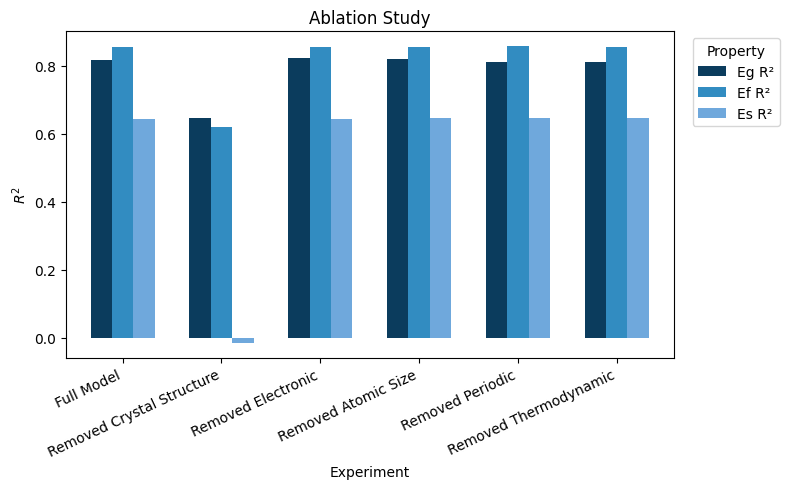

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import pandas as pd


def run_model(Xtr,Xte):

    m=RandomForestRegressor(n_estimators=500, max_depth=30, random_state=42, n_jobs=-1)
    m.fit(Xtr, y_train)

    p=m.predict(Xte)
    return [r2_score(y_test["Eg"], p[:,0]), r2_score(y_test["Ef"], p[:,1]), r2_score(y_test["Es"], p[:,2])]

results=[]


full=run_model(X_train, X_test)
results.append(["Full Model", full[0], full[1], full[2]])


for group,features in feature_groups.items():
    remaining=[col for col in X_train.columns if col not in features]
    score=run_model(X_train[remaining], X_test[remaining])


    results.append(["Removed "+group, score[0], score[1], score[2]])


ablation_results=pd.DataFrame(results, columns=["Experiment", "Eg R²", "Ef R²", "Es R²"])


print(ablation_results)

import matplotlib.pyplot as plt

plot = ablation_results.copy()
plot = plot.set_index("Experiment")
plot.plot(kind="bar", figsize=(8,5), width=0.65, color=["#0B3C5D", "#328CC1", "#6FA8DC"])
plt.ylabel("$R^2$")
plt.title("Ablation Study")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Property", loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

SHAP
- Purpose: a more advanced explanation of why the model predicted a certain value. Why did the model make this prediction? It is like XAI.
  - Feature importance is similar but it conveys which features the model used the most overall. It shows general trends and it can be biased towards certain features. It also does not explain individual compounds.
- Might only need it for Eg (Es and Ef are stability descriptors but Eg is directly related to solar efficiency)


In [25]:
import shap
import numpy as np
import pandas as pd

X_shap = X_test.sample(100, random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

print("SHAP calculated")
print(type(shap_values))

try:
    print(np.array(shap_values).shape)
except:
    pass

SHAP calculated
<class 'numpy.ndarray'>
(100, 202, 3)


SHAP type: <class 'numpy.ndarray'>
Detected SHAP array format
Shape: (100, 202, 3)
           Feature  Mean |SHAP|
36             vol     0.320955
11           x_std     0.167480
2         grp_mean     0.078057
27           k_std     0.054045
12        val_mean     0.052810
3          grp_std     0.037337
22        rho_mean     0.031172
20         bp_mean     0.029757
6   av_ionrad_mean     0.028963
13         val_std     0.028089
9     atom_rad_std     0.026191
33   spec_heat_std     0.025957
23         rho_std     0.025357
16         ie_mean     0.024230
35              of     0.023238
10          x_mean     0.020661
30   heat_vap_mean     0.020553
24         mp_mean     0.018959
26          k_mean     0.017196
34             gtf     0.015882


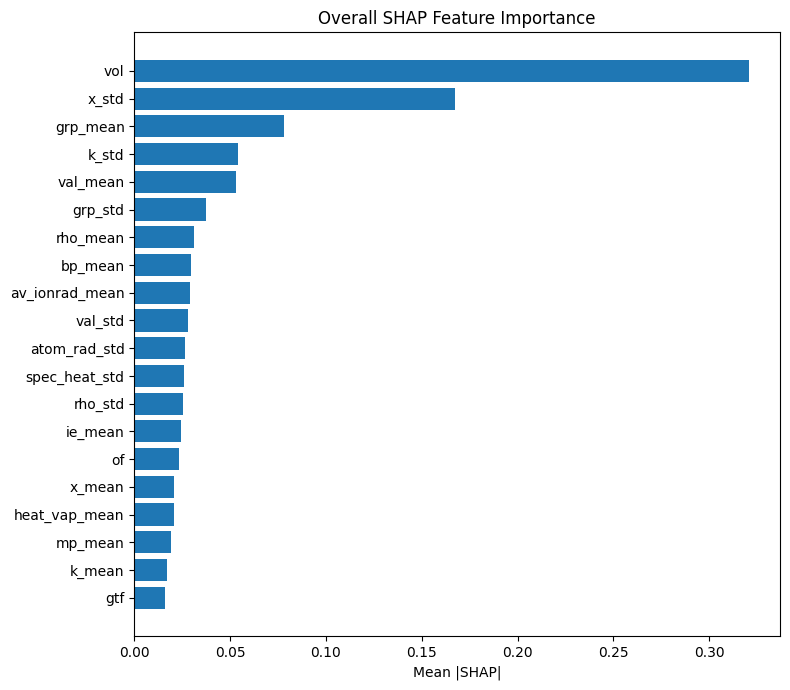

Band Gap SHAP


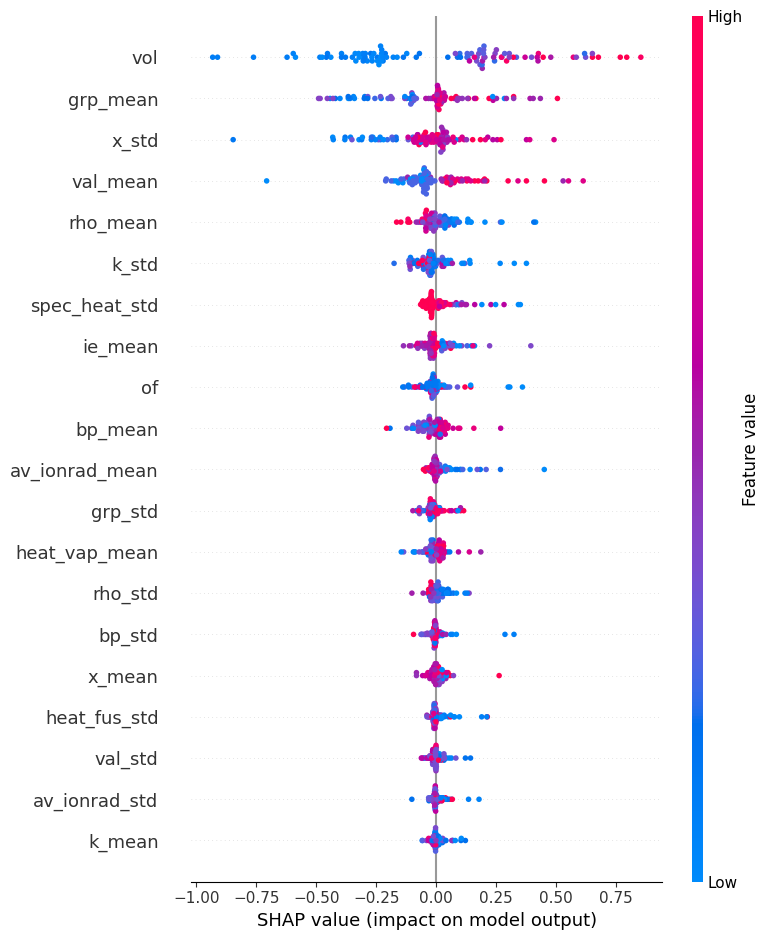

Formation Energy SHAP


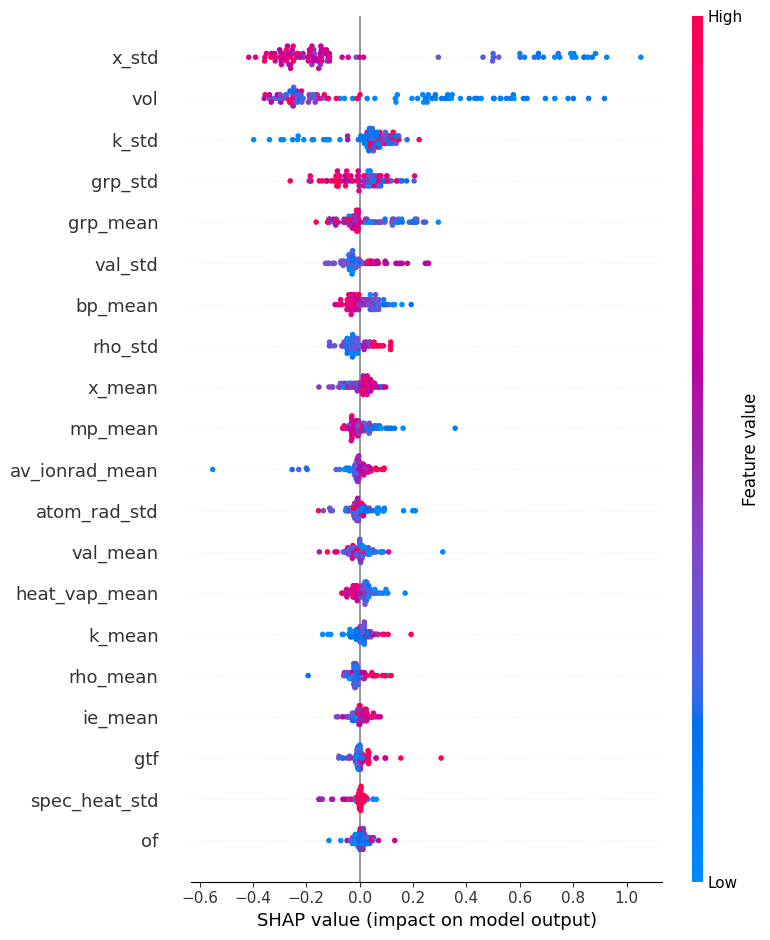

Stability Energy SHAP


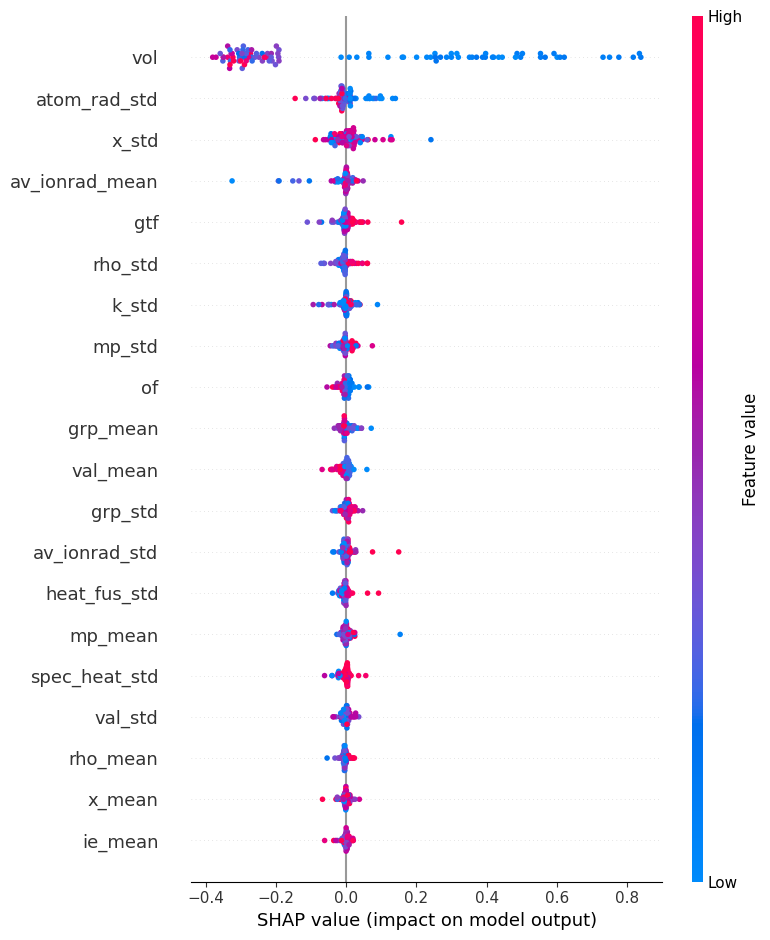

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap


print("SHAP type:", type(shap_values))

if isinstance(shap_values, list):

    print("Detected SHAP list format")

    combined = np.mean(
        [np.abs(values).mean(axis=0) for values in shap_values],
        axis=0)

    Eg_shap = shap_values[0]
    Ef_shap = shap_values[1]
    Es_shap = shap_values[2]


else:

    print("Detected SHAP array format")
    print("Shape:", shap_values.shape)

    combined = np.mean(np.abs(shap_values), axis=(0,2))

    Eg_shap = shap_values[:,:,0]
    Ef_shap = shap_values[:,:,1]
    Es_shap = shap_values[:,:,2]


shap_importance = pd.DataFrame({"Feature": X_shap.columns, "Mean |SHAP|": combined})
shap_importance = shap_importance.sort_values("Mean |SHAP|", ascending=False)
print(shap_importance.head(20))


top = shap_importance.head(20)
plt.figure(figsize=(8,7))
plt.barh(top["Feature"], top["Mean |SHAP|"])
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP|")
plt.title("Overall SHAP Feature Importance")
plt.tight_layout()
plt.show()

print("Band Gap SHAP")
shap.summary_plot(Eg_shap, X_shap, max_display=20)


print("Formation Energy SHAP")
shap.summary_plot(Ef_shap, X_shap, max_display=20)

print("Stability Energy SHAP")
shap.summary_plot(Es_shap, X_shap, max_display=20)

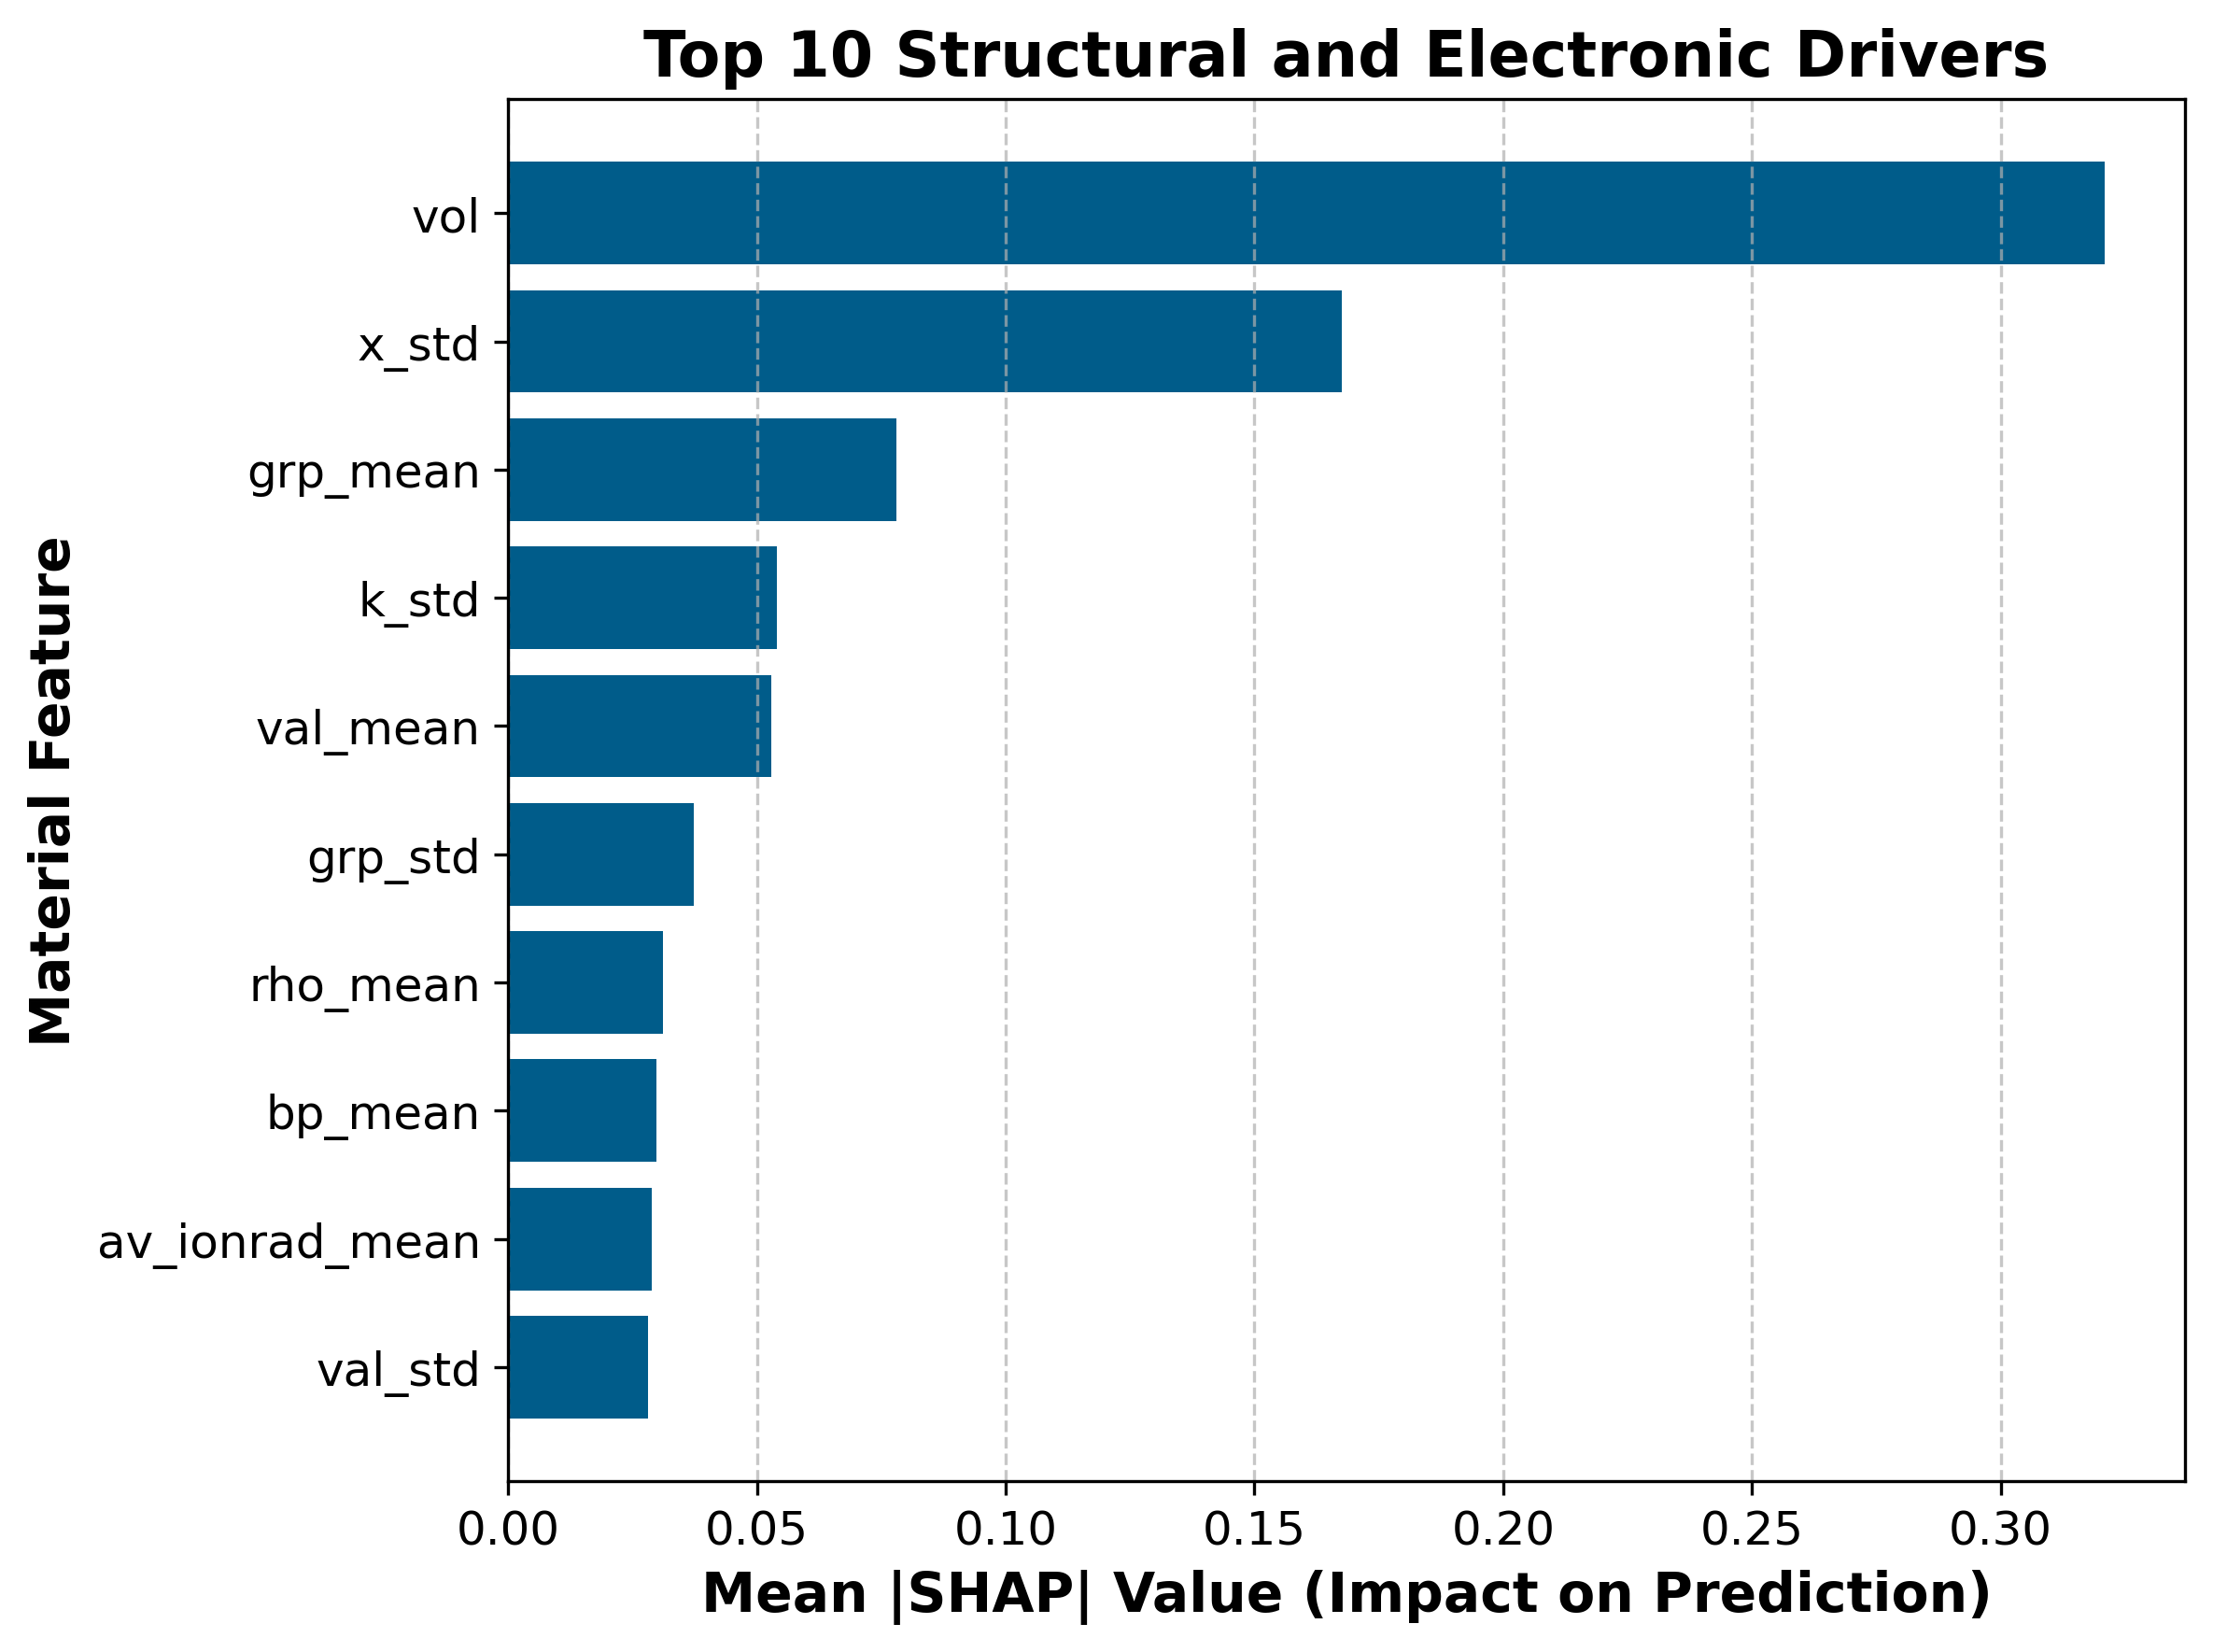

In [27]:
import matplotlib.pyplot as plt

top_10 = shap_importance.head(10).sort_values(by="Mean |SHAP|", ascending=True)

plt.figure(figsize=(8, 6), dpi=300)

plt.barh(top_10["Feature"], top_10["Mean |SHAP|"], color="#005C8A")

plt.xlabel("Mean |SHAP| Value (Impact on Prediction)", fontsize=14, fontweight='bold')
plt.ylabel("Material Feature", fontsize=14, fontweight='bold')
plt.title("Top 10 Structural and Electronic Drivers", fontsize=16, fontweight='bold')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("Feature_Importance_BarChart.png", bbox_inches='tight')
plt.show()

Sensitivity Analysis

In [28]:
important_features=[
    "vol",
    "grp_mean",
    "x_std",
    "val_mean"]

sensitivity=[]


for feature in important_features:
    modified=X_test.copy()
    modified[feature]=(modified[feature]*1.10)

    new_prediction=model.predict(modified)

    change = np.mean(np.abs(new_prediction - pred), axis=0)
    print(f"ΔEg: {change[0]:.4f}, ΔEf: {change[1]:.4f}, ΔEs: {change[2]:.4f}")


    sensitivity.append([feature, change])

sensitivity=pd.DataFrame(sensitivity, columns=["Feature", "Average Prediction Change"])
print(sensitivity)

ΔEg: 0.1570, ΔEf: 0.1682, ΔEs: 0.1626
ΔEg: 0.1766, ΔEf: 0.0795, ΔEs: 0.0237
ΔEg: 0.1156, ΔEf: 0.0841, ΔEs: 0.0271
ΔEg: 0.1669, ΔEf: 0.0912, ΔEs: 0.0213
    Feature                          Average Prediction Change
0       vol  [0.15695013550224504, 0.16818718662623922, 0.1...
1  grp_mean  [0.1765952730831305, 0.07951485915611757, 0.02...
2     x_std  [0.11562722324521375, 0.08414103017844214, 0.0...
3  val_mean  [0.16690292439186716, 0.09115615877749912, 0.0...


Baseline Comparison (the order of the input r^2 is {no crystal (individual), no crystal + no vol (individual), XGBoost (individual), no crystal (multi-output), Extra Trees (multi-output)}

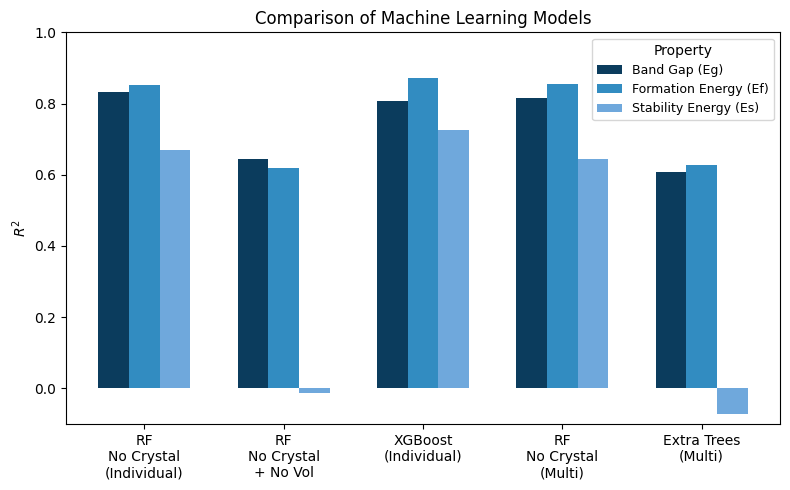

In [29]:
import pandas as pd

baseline = pd.DataFrame({
    "Model": [
        "RF\nNo Crystal\n(Individual)",
        "RF\nNo Crystal\n+ No Vol",
        "XGBoost\n(Individual)",
        "RF\nNo Crystal\n(Multi)",
        "Extra Trees\n(Multi)"],
    "Eg": [0.831, 0.644, 0.808, 0.816, 0.607],
    "Ef": [0.852, 0.619, 0.871, 0.855, 0.626],
    "Es": [0.670, -0.014, 0.726, 0.644, -0.071]
})

import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(baseline))
width = 0.22

plt.figure(figsize=(8,5))

plt.bar(x-width, baseline["Eg"], width, label="Band Gap (Eg)", color="#0B3C5D")
plt.bar(x, baseline["Ef"], width, label="Formation Energy (Ef)", color="#328CC1")
plt.bar(x+width, baseline["Es"], width, label="Stability Energy (Es)", color="#6FA8DC")

plt.xticks(x, baseline["Model"])
plt.ylabel("$R^2$")
plt.title("Comparison of Machine Learning Models")
plt.ylim(-0.1,1)

plt.legend(prop={'size': 9}, title = "Property", loc = "upper right")

plt.tight_layout()
plt.show()

Validation of the PSS

In [30]:
def photovoltaic_score(Eg,Es,Ef):

    sigma=0.20
    Eg_score=100*np.exp(-((Eg-1.34)**2) /(2*sigma**2))


    if Es<=0:
        Es_score=100

    elif Es<=0.05:
        Es_score=100-300*Es

    else:
        Es_score=max(0, 85*np.exp(-18*(Es-0.05)))

    Ef_score=min(100, max(0, -25*Ef))

    return (0.4*Eg_score+ 0.4*Es_score+ 0.2*Ef_score)

Correlation: 0.7426971046355412


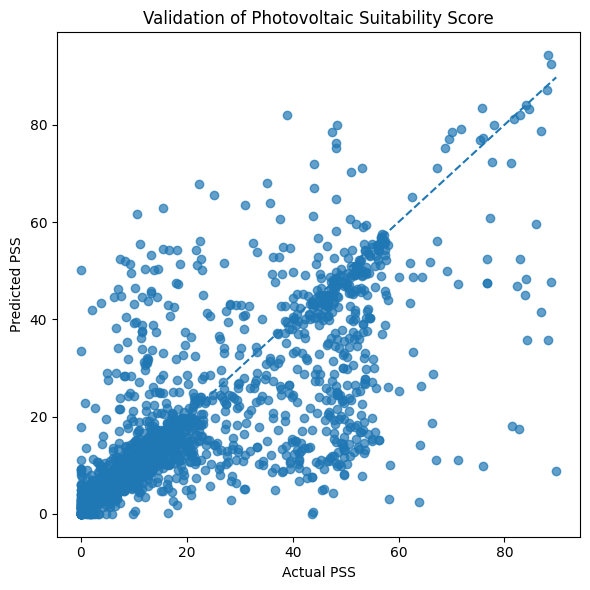

In [31]:
predicted_pss=[]
actual_pss=[]


for i in range(len(pred)):
    predicted_pss.append(photovoltaic_score(pred[i,0], pred[i,2], pred[i,1]))

    actual_pss.append(photovoltaic_score(y_test.iloc[i]["Eg"], y_test.iloc[i]["Es"], y_test.iloc[i]["Ef"]))


print("Correlation:", np.corrcoef(predicted_pss, actual_pss )[0,1])

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))
plt.scatter(actual_pss, predicted_pss, alpha=0.7)

minimum = min(actual_pss)
maximum = max(actual_pss)

plt.plot([minimum,maximum], [minimum,maximum],"--")
plt.xlabel("Actual PSS")
plt.ylabel("Predicted PSS")
plt.title("Validation of Photovoltaic Suitability Score")
plt.tight_layout()
plt.show()

Application Domain

In [34]:
import joblib
import os


results_checkpoint = {
    "model": model,
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test,

    "predictions": pred,

    "shap_values": shap_values,
    "shap_importance": shap_importance,

    "ablation_results": ablation_results,

    "sensitivity_results": sensitivity,

    "baseline_results": baseline,

    "actual_pss": actual_pss,
    "predicted_pss": predicted_pss
}


joblib.dump(results_checkpoint, "final_ML_analysis_checkpoint.pkl")


['final_ML_analysis_checkpoint.pkl']

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
